# Speech Emotion Recognition with CNNs on Mel-Spectrograms

This notebook trains and compares **5 CNN-based approaches** for classifying emotion from speech
audio (RAVDESS dataset), going from a naive baseline to a regularized model, data augmentation,
transfer learning, and finally transfer learning + augmentation combined.

**Experiments**

| # | Name | Idea |
|---|------|------|
| 1 | Baseline CNN | Plain CNN, no regularization — shows what overfitting looks like |
| 2 | Regularized CNN | + BatchNorm, Dropout, weight decay, LR scheduling, early stopping |
| 3 | Regularized CNN + Augmentation | + SpecAugment (time/freq masking) + Mixup |
| 4 | Transfer Learning | Pretrained ResNet18 adapted for single-channel mel-spectrograms |
| 5 | Transfer Learning + Augmentation | ResNet18 + SpecAugment + Mixup combined |

All experiments share **one fixed train/val/test split** and **one normalization scheme**, so
results are directly comparable.

> **Hardware note:** this notebook assumes a Kaggle GPU session (P100). The environment-setup cell
> below reinstalls a CUDA-matched PyTorch build, which is the fix used to resolve a CUDA/driver
> mismatch on Kaggle's P100 runtime. If your session already has a working GPU PyTorch install,
> you can skip that cell.

## 0. Environment Setup

**About the reinstall below:** Kaggle's default PyTorch build occasionally mismatches the
P100's CUDA driver, which shows up as `CUDA error: no kernel image is available for execution
on the device` or PyTorch silently falling back to CPU. Reinstalling a CUDA 12.6-targeted wheel
resolves this. This is a known, reasonable workaround for Kaggle P100 sessions — leave it in if
you've hit this error; comment it out if your environment is already fine, since it costs a
minute or two on every run.

In [1]:
# Reinstall PyTorch with a CUDA build that matches the Kaggle P100 runtime.
# Keep this if you've hit a CUDA/driver mismatch on Kaggle; comment out otherwise to save time.
!pip uninstall -y torch torchvision torchaudio -q
!pip install torch==2.7.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 165.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 223.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 171.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 67.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 90.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 120.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 187.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 140.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 109.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 147.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 123.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89.3 kB 101.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models as tv_models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed: int = SEED):
    """Make runs reproducible across numpy / python / torch (CPU + CUDA)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla P100-PCIE-16GB


## 1. Data Loading & Exploration

In [3]:
# Collect all .wav file paths from the RAVDESS dataset
wav_files = []
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if filename.endswith(".wav"):
            wav_files.append(os.path.join(dirname, filename))

print(f"Total audio files found: {len(wav_files):,}")
print("Sample paths:")
for p in wav_files[:3]:
    print("  ", p)

Total audio files found: 1,440
Sample paths:
   /kaggle/input/datasets/dejolilandry/ravdess/Radvess/Actor_02/03-01-08-01-01-01-02.wav
   /kaggle/input/datasets/dejolilandry/ravdess/Radvess/Actor_02/03-01-01-01-01-01-02.wav
   /kaggle/input/datasets/dejolilandry/ravdess/Radvess/Actor_02/03-01-07-02-01-02-02.wav


In [4]:
# RAVDESS filename convention: 03-01-EMOTION-...-ACTOR.wav
# The 3rd field is the emotion code.
EMOTIONS_MAP = {
    "01": "neutral",  "02": "calm",     "03": "happy",
    "04": "sad",       "05": "angry",    "06": "fearful",
    "07": "disgust",   "08": "surprised"
}

def get_emotion(path: str) -> str:
    """Extract the emotion label from a RAVDESS filename."""
    code = os.path.basename(path).split("-")[2]
    return EMOTIONS_MAP.get(code, "unknown")

df = pd.DataFrame({
    "path": wav_files,
    "emotion": [get_emotion(p) for p in wav_files]
})

# Drop anything that didn't match the naming convention, just in case
n_before = len(df)
df = df[df["emotion"] != "unknown"].reset_index(drop=True)
if len(df) < n_before:
    print(f"Dropped {n_before - len(df)} files with unrecognized emotion codes")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1440, 2)


,path,emotion
0,/kaggle/input/datasets/dejolilandry/ravdess/Ra...,surprised
1,/kaggle/input/datasets/dejolilandry/ravdess/Ra...,neutral
2,/kaggle/input/datasets/dejolilandry/ravdess/Ra...,disgust
3,/kaggle/input/datasets/dejolilandry/ravdess/Ra...,disgust
4,/kaggle/input/datasets/dejolilandry/ravdess/Ra...,neutral


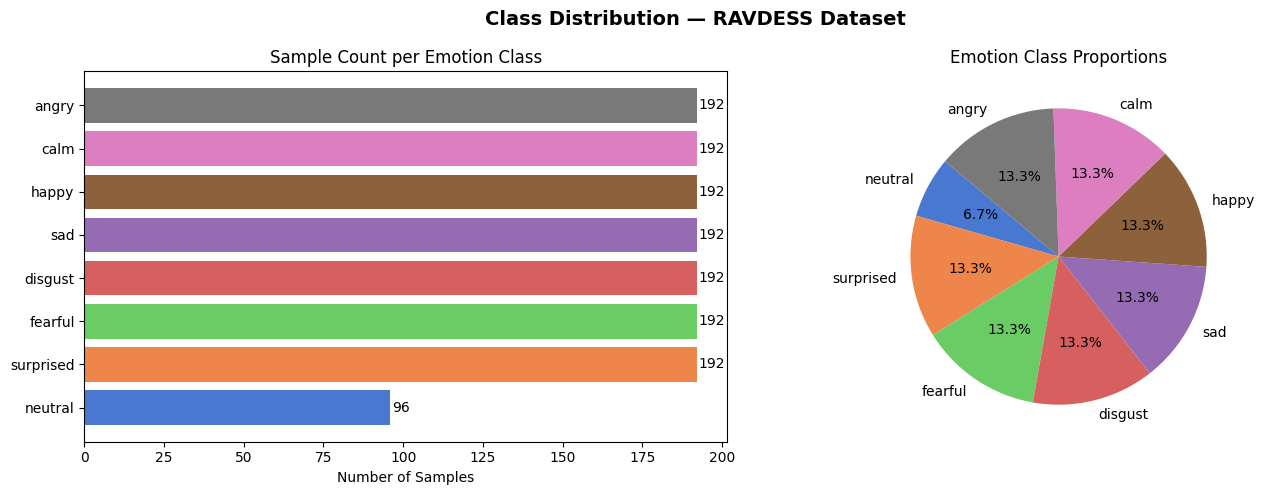

In [5]:
# Class distribution
label_counts = df["emotion"].value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(label_counts.index, label_counts.values,
             color=sns.color_palette("muted", len(label_counts)))
axes[0].set_xlabel("Number of Samples")
axes[0].set_title("Sample Count per Emotion Class")
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 0.5, i, str(v), va="center", fontsize=10)

axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("muted", len(label_counts)))
axes[1].set_title("Emotion Class Proportions")

plt.suptitle("Class Distribution — RAVDESS Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Feature Engineering

We extract log-mel spectrograms from each clip. First we check the duration distribution to pick
a sensible fixed clip length (pad short clips, truncate long ones) so every spectrogram has the
same shape.

In [6]:
durations = np.array([
    librosa.get_duration(path=p) for p in tqdm(df["path"], desc="Measuring durations")
])

print(f"Min duration:    {durations.min():.2f}s")
print(f"Mean duration:   {durations.mean():.2f}s")
print(f"Median duration: {np.median(durations):.2f}s")
print(f"Max duration:    {durations.max():.2f}s")
print(f"90th percentile: {np.percentile(durations, 90):.2f}s")
print(f"95th percentile: {np.percentile(durations, 95):.2f}s")
print(f"99th percentile: {np.percentile(durations, 99):.2f}s")

Measuring durations: 100%|██████████| 1440/1440 [00:22<00:00, 65.19it/s]

Min duration:    2.94s
Mean duration:   3.70s
Median duration: 3.67s
Max duration:    5.27s
90th percentile: 4.14s
95th percentile: 4.31s
99th percentile: 4.74s


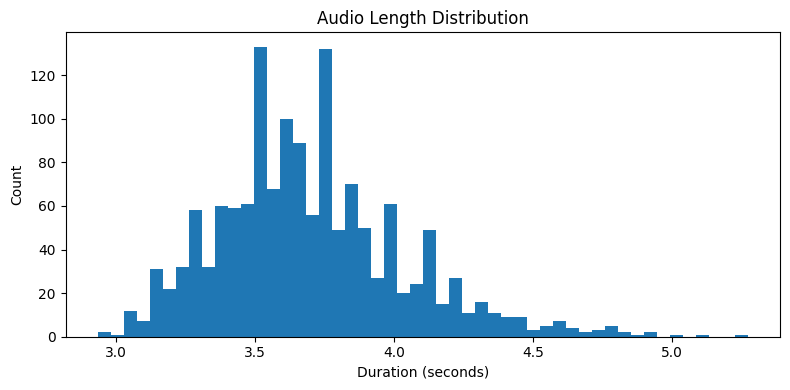

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(durations, bins=50)
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Audio Length Distribution")
plt.tight_layout()
plt.show()

In [8]:
SR = 22050          # sample rate
N_MELS = 128         # mel frequency bins
DURATION = 4         # seconds — covers ~90th percentile of clip lengths above
SAMPLES = SR * DURATION
N_FFT = 2048
HOP_LENGTH = 512

def extract_mel(path: str) -> np.ndarray:
    """Load an audio file, pad/truncate to a fixed length, and return a log-mel spectrogram."""
    signal, sr = librosa.load(path, sr=SR)

    if len(signal) < SAMPLES:
        signal = np.pad(signal, (0, SAMPLES - len(signal)))
    else:
        signal = signal[:SAMPLES]

    mel = librosa.feature.melspectrogram(
        y=signal, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

In [9]:
X, y = [], []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting mel-spectrograms"):
    X.append(extract_mel(row["path"]))
    y.append(row["emotion"])

X = np.array(X, dtype=np.float32)
y = np.array(y)

print(f"X shape: {X.shape}   (n_samples, n_mels, n_frames)")
print(f"X range: [{X.min():.2f}, {X.max():.2f}] dB | mean={X.mean():.2f}, std={X.std():.2f}")

encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(f"Classes: {list(encoder.classes_)}")

Extracting mel-spectrograms: 100%|██████████| 1440/1440 [00:44<00:00, 32.20it/s]


X shape: (1440, 128, 173)   (n_samples, n_mels, n_frames)
X range: [-80.00, 0.00] dB | mean=-64.69, std=18.39
Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]


## 3. Shared Train / Val / Test Split & Normalization

All 5 experiments use **the same split** and **the same normalization statistics**, so accuracy
differences between experiments reflect the modeling choice being tested — not a different slice
of data or a different feature scale.

We use a stratified 70 / 15 / 15 split, and normalize every spectrogram using the **training
set's** mean and standard deviation (never the val/test statistics — that would leak information
about the held-out data into preprocessing).

In [10]:
# 70% train, 15% val, 15% test — stratified so emotion proportions stay balanced in every split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 1008 | Val: 216 | Test: 216


In [11]:
# Normalize using TRAIN statistics only, then apply the same transform to val/test.
MEL_MEAN = X_train.mean()
MEL_STD = X_train.std()

def normalize(x):
    return (x - MEL_MEAN) / (MEL_STD + 1e-8)

X_train_norm = normalize(X_train)
X_val_norm = normalize(X_val)
X_test_norm = normalize(X_test)

print(f"Train mean/std used for normalization: {MEL_MEAN:.3f} / {MEL_STD:.3f}")
print(f"Normalized train range: [{X_train_norm.min():.2f}, {X_train_norm.max():.2f}]")

Train mean/std used for normalization: -64.656 / 18.396
Normalized train range: [-0.83, 3.51]


### Dataset classes

`AudioDataset` is the plain dataset used by Experiments 1, 2, and 4 (3-channel version for the
transfer-learning model is handled separately below). `AugmentedAudioDataset` adds **SpecAugment**
(time + frequency masking) for Experiments 3 and 5 — augmentation is applied **only when
`train=True`**, so validation and test data are never altered.

In [12]:
class AudioDataset(Dataset):
    """Plain dataset: normalized log-mel spectrograms, shape (1, n_mels, n_frames)."""

    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).unsqueeze(1)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def spec_augment(spec: torch.Tensor, n_time_masks=2, n_freq_masks=2,
                  time_mask_pct=0.10, freq_mask_pct=0.10) -> torch.Tensor:
    """
    SpecAugment (Park et al., 2019): randomly zero out contiguous time and
    frequency bands. Operates on a single (1, n_mels, n_frames) spectrogram.
    Values are masked with 0, which corresponds to the mean after normalization
    (not silence in dB terms), matching standard SpecAugment practice.
    """
    spec = spec.clone()
    _, n_mels, n_frames = spec.shape

    for _ in range(n_freq_masks):
        f_width = max(1, int(n_mels * freq_mask_pct))
        f0 = random.randint(0, max(0, n_mels - f_width))
        spec[:, f0:f0 + f_width, :] = 0.0

    for _ in range(n_time_masks):
        t_width = max(1, int(n_frames * time_mask_pct))
        t0 = random.randint(0, max(0, n_frames - t_width))
        spec[:, :, t0:t0 + t_width] = 0.0

    return spec


class AugmentedAudioDataset(Dataset):
    """
    Same as AudioDataset, but applies SpecAugment on-the-fly when train=True.
    Mixup is handled separately at the batch level (see mixup_batch below),
    since it needs to mix pairs of samples, not just one at a time.
    """

    def __init__(self, X, y, train: bool = True):
        self.X = torch.FloatTensor(X).unsqueeze(1)
        self.y = torch.LongTensor(y)
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.train:
            x = spec_augment(x)
        return x, self.y[idx]


def mixup_batch(x, y, num_classes, alpha=0.2):
    """
    Mixup (Zhang et al., 2018): blend pairs of inputs and their one-hot labels.
    Returns mixed inputs and soft labels; use with a loss that accepts soft
    targets (we implement a small soft-label cross-entropy below).
    """
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    perm = torch.randperm(x.size(0), device=x.device)

    x_mixed = lam * x + (1 - lam) * x[perm]

    y_onehot = F.one_hot(y, num_classes=num_classes).float()
    y_mixed = lam * y_onehot + (1 - lam) * y_onehot[perm]

    return x_mixed, y_mixed


def soft_ce_loss(logits, soft_targets):
    """Cross-entropy that accepts soft (mixup) targets instead of hard class indices."""
    log_probs = F.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()

### Quick sanity check: visualize a sample spectrogram

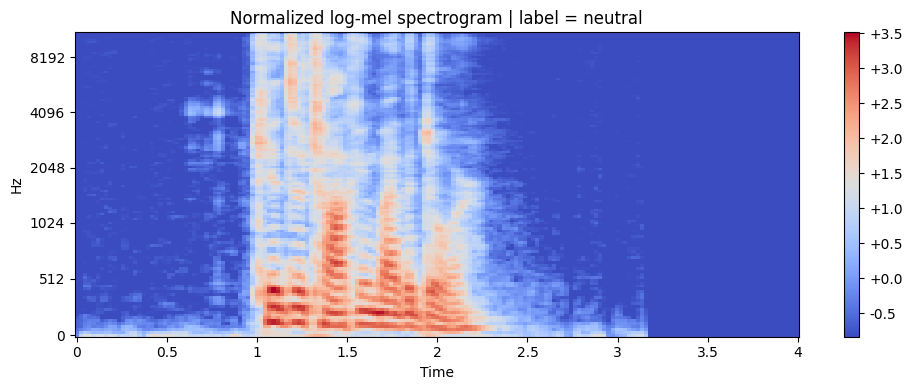

In [13]:
sample_dataset = AudioDataset(X_train_norm, y_train)
x_sample, y_sample = sample_dataset[1]

plt.figure(figsize=(10, 4))
librosa.display.specshow(x_sample[0].numpy(), sr=SR, hop_length=HOP_LENGTH,
                          x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.1f")
plt.title(f"Normalized log-mel spectrogram | label = {encoder.classes_[y_sample]}")
plt.tight_layout()
plt.show()

### Shared training utilities

A reusable training loop (with early stopping + LR scheduling) and evaluation function, so every
experiment calls the same code instead of duplicating the loop 5 times. We keep a `results`
dictionary to collect metrics for the final comparison.

In [14]:
results = {}  # populated by each experiment: results[name] = {"test_acc": ..., "train_acc": ..., ...}


def train_model(model, train_loader, val_loader, optimizer, scheduler=None,
                 criterion=None, num_epochs=200, patience=10, use_mixup=False,
                 num_classes=None, model_name="model", verbose_every=5):
    """
    Generic training loop with early stopping on validation loss.
    If use_mixup=True, applies mixup to each training batch and uses a soft-label
    cross-entropy; validation always uses plain (unmixed) data and standard CE.
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    counter = 0
    history = {"train_loss": [], "val_loss": []}
    ckpt_path = f"/kaggle/working/{model_name}_best.pth"

    for epoch in range(num_epochs):
        # ---- Train ----
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()

            if use_mixup:
                X_mixed, y_mixed = mixup_batch(X_batch, y_batch, num_classes)
                outputs = model(X_mixed)
                loss = soft_ce_loss(outputs, y_mixed)
            else:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # ---- Validate (always on clean, unaugmented data) ----
        model.eval()
        running_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                running_loss += loss.item()
        val_loss = running_loss / len(val_loader)

        if scheduler is not None:
            scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if (epoch + 1) % verbose_every == 0 or epoch == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(f"Epoch {epoch+1:03d} | Train Loss={train_loss:.4f} | "
                  f"Val Loss={val_loss:.4f} | LR={lr:.6f}")

        # ---- Early stopping ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1} (best val loss={best_val_loss:.4f})")
                break

    model.load_state_dict(torch.load(ckpt_path))
    return model, history


@torch.no_grad()
def evaluate(model, loader):
    """Run inference over a loader and return (accuracy, y_true, y_pred)."""
    model.eval()
    y_true, y_pred = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(y_batch.numpy())
        y_pred.extend(predicted.cpu().numpy())
    return accuracy_score(y_true, y_pred), np.array(y_true), np.array(y_pred)


def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Experiment 1 — Baseline CNN

This experiment establishes a baseline using a simple convolutional neural network trained entirely from scratch. The architecture intentionally avoids modern regularization and optimization techniques such as Batch Normalization, weight decay, learning-rate scheduling, and early stopping, allowing the model to learn without additional constraints.

Unlike later experiments, the network is trained for a large fixed number of epochs (3,000), giving it sufficient opportunity to fit the training data. This provides a meaningful reference point for evaluating how subsequent regularization strategies, data augmentation, and transfer learning affect both performance and generalization.

The goal of this experiment is not to achieve the highest possible accuracy, but to demonstrate the behavior of a straightforward CNN trained on a relatively small dataset. The remaining experiments progressively introduce techniques designed to improve generalization and reduce overfitting while increasing classification accuracy.

In [15]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [16]:
set_seed(SEED)

train_dataset_1 = AudioDataset(X_train_norm, y_train)
val_dataset_1 = AudioDataset(X_val_norm, y_val)
test_dataset_1 = AudioDataset(X_test_norm, y_test)

train_loader_1 = DataLoader(train_dataset_1, batch_size=128, shuffle=True)
val_loader_1 = DataLoader(val_dataset_1, batch_size=128)
test_loader_1 = DataLoader(test_dataset_1, batch_size=128)

model_1 = BaselineCNN(num_classes=len(encoder.classes_)).to(device)
criterion_1 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(model_1.parameters(),lr=1e-4)

# Deliberately no early stopping here -- fixed epoch budget, to let it overfit
# so the effect is visible. (Compare to Experiment 2, which adds early stopping.)
NUM_EPOCHS_BASELINE = 3000

history_1 = {"train_loss": [], "val_loss": []}

for epoch in range(NUM_EPOCHS_BASELINE):
    model_1.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader_1:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_1.zero_grad()
        outputs = model_1(X_batch)
        loss = criterion_1(outputs, y_batch)
        loss.backward()
        optimizer_1.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader_1)

    model_1.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader_1:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_1(X_batch)
            loss = criterion_1(outputs, y_batch)
            running_loss += loss.item()
    val_loss = running_loss / len(val_loader_1)

    history_1["train_loss"].append(train_loss)
    history_1["val_loss"].append(val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d} | Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f}")

Epoch 01 | Train Loss=2.0827 | Val Loss=2.0794
Epoch 05 | Train Loss=2.0719 | Val Loss=2.0710
Epoch 10 | Train Loss=2.0639 | Val Loss=2.0663
Epoch 15 | Train Loss=2.0575 | Val Loss=2.0601
Epoch 20 | Train Loss=2.0474 | Val Loss=2.0519
Epoch 25 | Train Loss=2.0342 | Val Loss=2.0432
Epoch 30 | Train Loss=2.0266 | Val Loss=2.0338
Epoch 35 | Train Loss=2.0186 | Val Loss=2.0232
Epoch 40 | Train Loss=1.9987 | Val Loss=2.0166
Epoch 45 | Train Loss=1.9946 | Val Loss=2.0080
Epoch 50 | Train Loss=1.9937 | Val Loss=2.0003
Epoch 55 | Train Loss=1.9731 | Val Loss=1.9964
Epoch 60 | Train Loss=1.9687 | Val Loss=1.9931
Epoch 65 | Train Loss=1.9664 | Val Loss=1.9879
Epoch 70 | Train Loss=1.9601 | Val Loss=1.9811
Epoch 75 | Train Loss=1.9514 | Val Loss=1.9733
Epoch 80 | Train Loss=1.9497 | Val Loss=1.9666
Epoch 85 | Train Loss=1.9389 | Val Loss=1.9607
Epoch 90 | Train Loss=1.9436 | Val Loss=1.9492
Epoch 95 | Train Loss=1.9155 | Val Loss=1.9373
Epoch 100 | Train Loss=1.9051 | Val Loss=1.9251
Epoch 105 | 

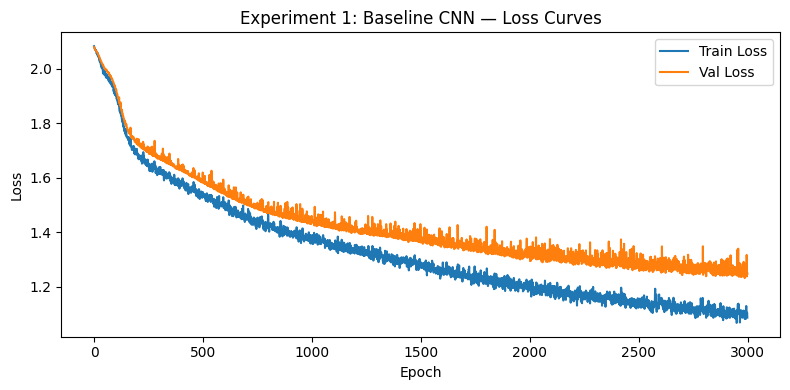

Train Accuracy: 0.6300
Test Accuracy:  0.5324
Train/Test gap: 0.0976
              precision    recall  f1-score   support

       angry       0.55      0.43      0.48        28
        calm       0.66      0.79      0.72        29
     disgust       0.51      0.62      0.56        29
     fearful       0.51      0.62      0.56        29
       happy       0.42      0.34      0.38        29
     neutral       0.41      0.50      0.45        14
         sad       0.36      0.17      0.23        29
   surprised       0.65      0.76      0.70        29

    accuracy                           0.53       216
   macro avg       0.51      0.53      0.51       216
weighted avg       0.51      0.53      0.51       216



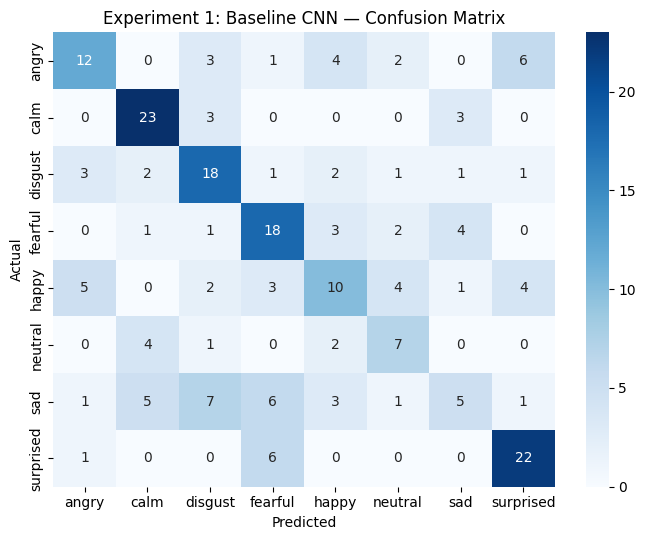

In [17]:
plot_history(history_1, "Experiment 1: Baseline CNN — Loss Curves")

test_acc_1, yt_1, yp_1 = evaluate(model_1, test_loader_1)
train_acc_1, _, _ = evaluate(model_1, train_loader_1)

print(f"Train Accuracy: {train_acc_1:.4f}")
print(f"Test Accuracy:  {test_acc_1:.4f}")
print(f"Train/Test gap: {train_acc_1 - test_acc_1:.4f}")

print(classification_report(yt_1, yp_1, target_names=encoder.classes_))
plot_confusion(yt_1, yp_1, "Experiment 1: Baseline CNN — Confusion Matrix")

results["1. Baseline CNN"] = {
    "train_acc": train_acc_1, "test_acc": test_acc_1,
    "gap": train_acc_1 - test_acc_1
}

## Experiment 2 — Regularized CNN

Same backbone idea, strengthened with techniques that reliably reduce overfitting on small image-
like datasets:

- **Batch Normalization** — stabilizes and speeds up training
- **Progressive Dropout** — increasing dropout deeper into the network
- **Weight decay (L2)** — penalizes large weights
- **ReduceLROnPlateau** — lowers the learning rate when validation loss stalls
- **Early stopping** — stops training once validation loss stops improving, restoring the best checkpoint

This uses the same shared train/val/test split and normalized features as Experiment 1, so the
comparison is fair.

In [18]:
class RegularizedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.40),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.50),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.60),

            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.60),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [19]:
set_seed(SEED)

# Reuse the same loaders as Experiment 1 -- same split, same normalization
train_loader_2, val_loader_2, test_loader_2 = train_loader_1, val_loader_1, test_loader_1

model_2 = RegularizedCNN(num_classes=len(encoder.classes_)).to(device)
criterion_2 = nn.CrossEntropyLoss()

optimizer_2 = torch.optim.Adam(model_2.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_2, mode="min", factor=0.5, patience=30, min_lr=1e-6
)

model_2, history_2 = train_model(
    model_2, train_loader_2, val_loader_2, optimizer_2, scheduler_2,
    criterion=criterion_2, num_epochs=1000, patience=100, model_name="exp2_regularized"
)

Epoch 001 | Train Loss=2.0927 | Val Loss=2.0696 | LR=0.001000
Epoch 005 | Train Loss=1.9764 | Val Loss=2.0420 | LR=0.001000
Epoch 010 | Train Loss=1.8110 | Val Loss=2.1660 | LR=0.001000
Epoch 015 | Train Loss=1.6871 | Val Loss=2.0224 | LR=0.001000
Epoch 020 | Train Loss=1.6077 | Val Loss=1.9843 | LR=0.001000
Epoch 025 | Train Loss=1.5581 | Val Loss=1.7388 | LR=0.001000
Epoch 030 | Train Loss=1.4954 | Val Loss=1.8091 | LR=0.001000
Epoch 035 | Train Loss=1.4553 | Val Loss=1.8016 | LR=0.001000
Epoch 040 | Train Loss=1.4212 | Val Loss=1.6362 | LR=0.001000
Epoch 045 | Train Loss=1.3881 | Val Loss=1.5884 | LR=0.001000
Epoch 050 | Train Loss=1.3669 | Val Loss=1.4571 | LR=0.001000
Epoch 055 | Train Loss=1.3475 | Val Loss=1.7865 | LR=0.001000
Epoch 060 | Train Loss=1.3262 | Val Loss=1.7381 | LR=0.001000
Epoch 065 | Train Loss=1.2832 | Val Loss=1.4416 | LR=0.001000
Epoch 070 | Train Loss=1.2534 | Val Loss=1.4285 | LR=0.001000
Epoch 075 | Train Loss=1.2654 | Val Loss=1.5617 | LR=0.001000
Epoch 08

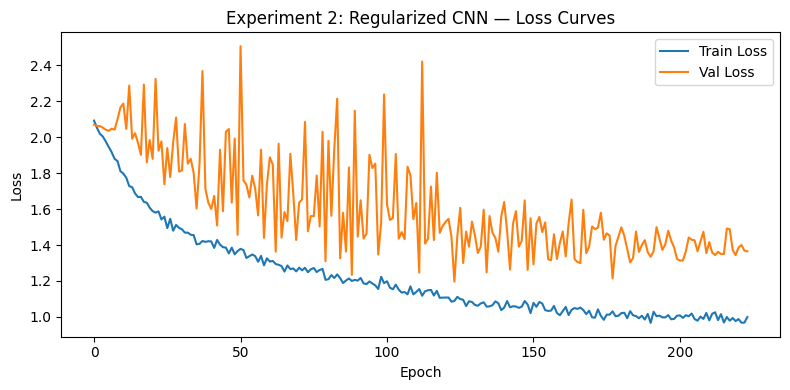

Train Accuracy: 0.6260
Test Accuracy:  0.6065
Train/Test gap: 0.0195
              precision    recall  f1-score   support

       angry       0.62      0.75      0.68        28
        calm       0.55      1.00      0.71        29
     disgust       0.83      0.86      0.85        29
     fearful       0.64      0.62      0.63        29
       happy       0.42      0.17      0.24        29
     neutral       0.36      0.36      0.36        14
         sad       0.39      0.31      0.35        29
   surprised       0.86      0.66      0.75        29

    accuracy                           0.61       216
   macro avg       0.58      0.59      0.57       216
weighted avg       0.60      0.61      0.58       216



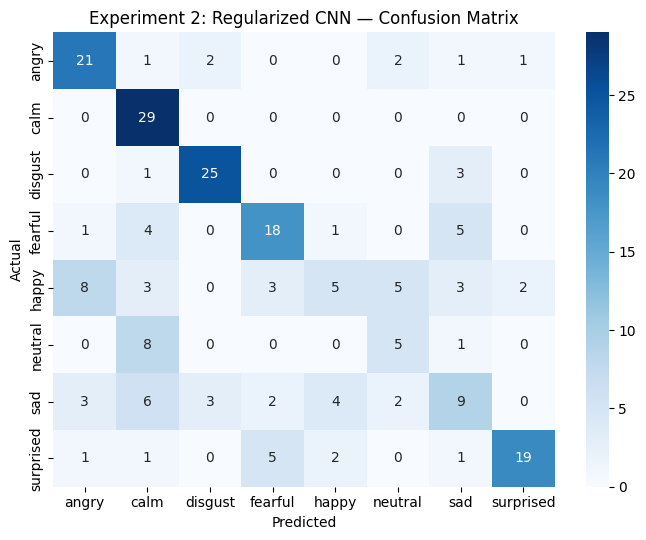

In [20]:
plot_history(history_2, "Experiment 2: Regularized CNN — Loss Curves")

test_acc_2, yt_2, yp_2 = evaluate(model_2, test_loader_2)
train_acc_2, _, _ = evaluate(model_2, train_loader_2)

print(f"Train Accuracy: {train_acc_2:.4f}")
print(f"Test Accuracy:  {test_acc_2:.4f}")
print(f"Train/Test gap: {train_acc_2 - test_acc_2:.4f}")

print(classification_report(yt_2, yp_2, target_names=encoder.classes_))
plot_confusion(yt_2, yp_2, "Experiment 2: Regularized CNN — Confusion Matrix")

results["2. Regularized CNN"] = {
    "train_acc": train_acc_2, "test_acc": test_acc_2,
    "gap": train_acc_2 - test_acc_2
}

## Experiment 3 — Regularized CNN + Data Augmentation (SpecAugment + Mixup)

Complex architecture but with soft regularization, but now the training data also gets the following:

- **SpecAugment** — random time and frequency masking applied per-sample (defined in section 3)
- **Mixup** — random convex combinations of pairs of training samples and their labels, applied
per batch inside the training loop

Both are **train-only**: validation and test data are evaluated on clean, unaugmented
spectrograms, so the test accuracy below is a fair comparison against Experiments 1 and 2.

In [21]:
class Regularized2CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.10),

            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.10),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [22]:
set_seed(SEED)

train_dataset_3 = AugmentedAudioDataset(X_train_norm, y_train, train=True)
val_dataset_3 = AudioDataset(X_val_norm, y_val)      # no augmentation at eval time
test_dataset_3 = AudioDataset(X_test_norm, y_test)   # no augmentation at eval time

train_loader_3 = DataLoader(train_dataset_3, batch_size=128, shuffle=True)
val_loader_3 = DataLoader(val_dataset_3, batch_size=128)
test_loader_3 = DataLoader(test_dataset_3, batch_size=128)

model_3 = Regularized2CNN(num_classes=len(encoder.classes_)).to(device)
criterion_3 = nn.CrossEntropyLoss()

optimizer_3 = torch.optim.Adam(model_3.parameters(), lr=1e-3, weight_decay=0)
scheduler_3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_3, mode="min", factor=0.5, patience=5, min_lr=1e-6
)

model_3, history_3 = train_model(
    model_3, train_loader_3, val_loader_3, optimizer_3, scheduler_3,
    criterion=criterion_3, num_epochs=1000, patience=100, use_mixup=True,
    num_classes=len(encoder.classes_), model_name="exp3_augmented"
)

Epoch 001 | Train Loss=2.0594 | Val Loss=2.0802 | LR=0.001000
Epoch 005 | Train Loss=1.7989 | Val Loss=2.1274 | LR=0.001000
Epoch 010 | Train Loss=1.5662 | Val Loss=1.6674 | LR=0.001000
Epoch 015 | Train Loss=1.3178 | Val Loss=1.6362 | LR=0.000500
Epoch 020 | Train Loss=1.4797 | Val Loss=1.5186 | LR=0.000500
Epoch 025 | Train Loss=1.3412 | Val Loss=1.2735 | LR=0.000250
Epoch 030 | Train Loss=1.1836 | Val Loss=1.5602 | LR=0.000125
Epoch 035 | Train Loss=1.0096 | Val Loss=1.1756 | LR=0.000125
Epoch 040 | Train Loss=0.9887 | Val Loss=1.0837 | LR=0.000125
Epoch 045 | Train Loss=1.0507 | Val Loss=1.1577 | LR=0.000063
Epoch 050 | Train Loss=1.0138 | Val Loss=1.0021 | LR=0.000063
Epoch 055 | Train Loss=0.8648 | Val Loss=1.0416 | LR=0.000063
Epoch 060 | Train Loss=1.0673 | Val Loss=1.0474 | LR=0.000031
Epoch 065 | Train Loss=1.1077 | Val Loss=1.0472 | LR=0.000031
Epoch 070 | Train Loss=0.9492 | Val Loss=1.0049 | LR=0.000016
Epoch 075 | Train Loss=0.9921 | Val Loss=0.9865 | LR=0.000008
Epoch 08

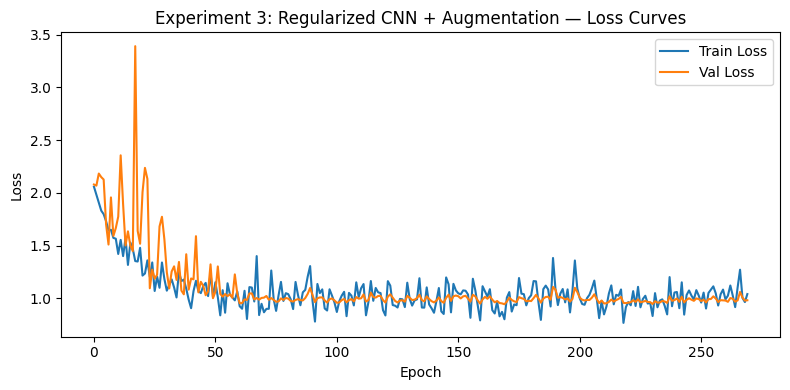

Train Accuracy (clean, no augmentation): 0.8988
Test Accuracy:                           0.6759
Train/Test gap:                          0.2229
              precision    recall  f1-score   support

       angry       0.62      0.71      0.67        28
        calm       0.76      0.76      0.76        29
     disgust       0.77      0.83      0.80        29
     fearful       0.66      0.79      0.72        29
       happy       0.61      0.38      0.47        29
     neutral       0.67      0.57      0.62        14
         sad       0.48      0.48      0.48        29
   surprised       0.80      0.83      0.81        29

    accuracy                           0.68       216
   macro avg       0.67      0.67      0.67       216
weighted avg       0.67      0.68      0.67       216



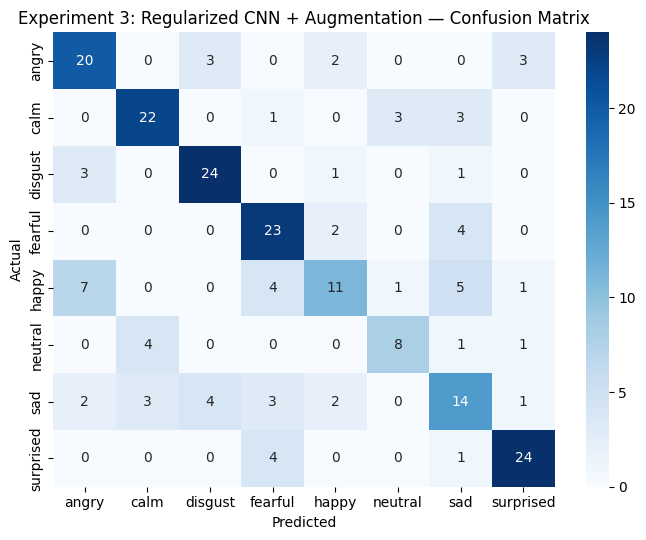

In [23]:
plot_history(history_3, "Experiment 3: Regularized CNN + Augmentation — Loss Curves")

test_acc_3, yt_3, yp_3 = evaluate(model_3, test_loader_3)

# Measure train accuracy on a CLEAN (non-augmented) copy of the training set, so it's
# comparable to Experiments 1 and 2 (train_loader_3 itself still applies SpecAugment).
clean_train_loader_3 = DataLoader(AudioDataset(X_train_norm, y_train), batch_size=32)
train_acc_3_clean, _, _ = evaluate(model_3, clean_train_loader_3)

print(f"Train Accuracy (clean, no augmentation): {train_acc_3_clean:.4f}")
print(f"Test Accuracy:                           {test_acc_3:.4f}")
print(f"Train/Test gap:                          {train_acc_3_clean - test_acc_3:.4f}")

print(classification_report(yt_3, yp_3, target_names=encoder.classes_))
plot_confusion(yt_3, yp_3, "Experiment 3: Regularized CNN + Augmentation — Confusion Matrix")

results["3. Regularized CNN + Augmentation"] = {
    "train_acc": train_acc_3_clean, "test_acc": test_acc_3,
    "gap": train_acc_3_clean - test_acc_3
}

## **Experiment 4 — Transfer Learning (ResNet18)**

The previous experiments explored progressively stronger convolutional neural networks trained entirely from scratch on the RAVDESS dataset. The baseline CNN demonstrated that a simple architecture could learn meaningful representations from mel-spectrograms but achieved only moderate classification performance. Incorporating regularization techniques, including Batch Normalization, Dropout, weight decay, adaptive learning-rate scheduling, and early stopping, improved the model's predictive performance while maintaining a train-test gap comparable to the baseline.

Increasing the model capacity and introducing SpecAugment and MixUp further improved classification accuracy, demonstrating that the CNN could benefit from stronger feature extraction and data augmentation. However, these improvements were accompanied by a substantially larger train-test gap, indicating that the deeper network increasingly memorized the limited training data. Although the model achieved higher predictive performance, its ability to generalize remained constrained by the relatively small size of the RAVDESS dataset.

These observations suggest that the primary limitation is not the convolutional architecture itself, but the difficulty of learning rich and transferable feature representations from scratch using only a limited amount of labeled speech data.

To address this limitation, this experiment adopts **transfer learning** by leveraging a **ResNet18** model pretrained on ImageNet. Instead of learning all feature representations from scratch, the model begins with feature detectors learned from millions of natural images and adapts them to the speech emotion recognition task.

Although originally designed for image classification, ResNet18 has become one of the most widely adopted backbone architectures for audio classification by treating spectrograms as images. The pretrained network already contains rich low-level feature detectors, including edge, texture, and shape filters, which also capture meaningful time-frequency structures in mel-spectrograms. Reusing these learned representations allows the network to converge more rapidly while providing a stronger feature extraction foundation than can typically be learned from a small audio dataset alone.

### **Adapting ResNet18 for Mel Spectrograms**

The original ResNet18 expects three-channel RGB images (`in_channels=3`), whereas mel-spectrograms are represented as single-channel grayscale images. Rather than replicating the spectrogram across three identical channels, the first convolutional layer is replaced with a single-channel convolution (`in_channels=1`). To preserve as much pretrained information as possible, the new convolution is initialized using the average of the pretrained RGB filters across the channel dimension. This initialization retains the learned low-level feature detectors while adapting the network to process single-channel spectrograms directly.

The original ImageNet classification layer is replaced with a new fully connected classifier designed specifically for the eight emotion categories in the RAVDESS dataset.

### **Fine-Tuning Strategy**

Instead of retraining the entire network, the early backbone layers remain frozen while the higher-level layers and the new classification head are fine-tuned. The lower layers primarily capture generic visual primitives that transfer well across domains, whereas the deeper layers learn task-specific representations that can be adapted to speech emotion recognition. Freezing the early layers reduces the number of trainable parameters, decreases computational cost, and helps limit overfitting on the relatively small training set.

To ensure a fair comparison with the previous CNN-based experiments, the same optimization framework is retained, including adaptive learning-rate scheduling, early stopping, and weight decay. Consequently, the principal methodological difference in this experiment is the use of pretrained feature representations, allowing the contribution of transfer learning to be evaluated directly.


In [24]:
def build_resnet18_for_mel(
    num_classes,
    freeze_layers=("conv1", "bn1", "layer1", "layer2")
):
    """
    Build an ImageNet-pretrained ResNet18 for single-channel mel spectrograms.

    Parameters
    ----------
    num_classes : int
        Number of output classes.

    freeze_layers : tuple[str]
        Backbone layers to freeze.
        Possible values:
            "conv1"
            "bn1"
            "layer1"
            "layer2"
            "layer3"
            "layer4"

        Example:
            ("conv1","bn1","layer1","layer2")
    """

    # -------------------------------
    # Load pretrained model
    # -------------------------------
    resnet = tv_models.resnet18(
        weights=tv_models.ResNet18_Weights.IMAGENET1K_V1
    )

    # -------------------------------
    # Convert first conv from RGB -> grayscale
    # -------------------------------
    old_conv = resnet.conv1

    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    with torch.no_grad():
        new_conv.weight.copy_(
            old_conv.weight.mean(dim=1, keepdim=True)
        )

    resnet.conv1 = new_conv

    # -------------------------------
    # Replace classifier
    # -------------------------------
    in_features = resnet.fc.in_features

    resnet.fc = nn.Sequential(
        nn.Linear(in_features, 64),
        nn.ReLU(inplace=True),
        nn.Linear(64, num_classes)
        
    )
    
    # -------------------------------
    # Freeze requested layers
    # -------------------------------
    for name, param in resnet.named_parameters():

        if any(name.startswith(layer) for layer in freeze_layers):
            param.requires_grad = False

    return resnet

ResNet18 expects roughly ImageNet-sized inputs and was trained on 3-channel statistics, but
since we replaced `conv1` for 1-channel input, we just need spectrograms at a reasonable spatial
resolution. Our mel-spectrograms are `(128, 173)`, which `AdaptiveAvgPool2d` inside ResNet handles
natively regardless of exact size — no resizing required.

In [25]:
set_seed(SEED)

train_dataset_4 = AudioDataset(X_train_norm, y_train)
val_dataset_4 = AudioDataset(X_val_norm, y_val)
test_dataset_4 = AudioDataset(X_test_norm, y_test)

train_loader_4 = DataLoader(train_dataset_4, batch_size=32, shuffle=True)
val_loader_4 = DataLoader(val_dataset_4, batch_size=32)
test_loader_4 = DataLoader(test_dataset_4, batch_size=32)

model_4 = build_resnet18_for_mel(
    num_classes=len(encoder.classes_),
    freeze_layers=("conv1", "bn1", "layer1","layer2")
).to(device)

criterion_4 = nn.CrossEntropyLoss()

optimizer_4 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_4.parameters()),
    lr=1e-4,
    weight_decay=5e-1
)

scheduler_4 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_4, mode="min", factor=0.5, patience=5, min_lr=1e-6
)
trainable = sum(p.numel() for p in model_4.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_4.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

model_4, history_4 = train_model(
    model_4, train_loader_4, val_loader_4, optimizer_4, scheduler_4,
    criterion=criterion_4, num_epochs=200, patience=50, model_name="exp4_resnet18"
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 210MB/s]


Trainable params: 10,526,792 / 11,203,592 (94.0%)
Epoch 001 | Train Loss=1.7968 | Val Loss=1.5965 | LR=0.000100
Epoch 005 | Train Loss=0.0583 | Val Loss=0.9814 | LR=0.000100
Epoch 010 | Train Loss=0.0117 | Val Loss=0.9778 | LR=0.000100
Epoch 015 | Train Loss=0.0055 | Val Loss=0.9644 | LR=0.000050
Epoch 020 | Train Loss=0.0044 | Val Loss=0.9603 | LR=0.000025
Epoch 025 | Train Loss=0.0045 | Val Loss=0.9886 | LR=0.000025
Epoch 030 | Train Loss=0.0043 | Val Loss=0.9725 | LR=0.000013
Epoch 035 | Train Loss=0.0038 | Val Loss=0.9960 | LR=0.000006
Epoch 040 | Train Loss=0.0059 | Val Loss=0.9617 | LR=0.000003
Epoch 045 | Train Loss=0.0033 | Val Loss=0.9716 | LR=0.000002
Epoch 050 | Train Loss=0.0033 | Val Loss=0.9578 | LR=0.000001
Epoch 055 | Train Loss=0.0032 | Val Loss=0.9687 | LR=0.000001
Early stopping at epoch 58 (best val loss=0.9468)


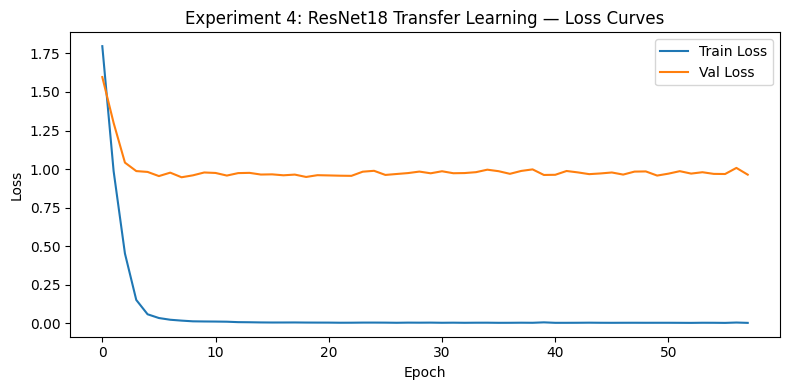

Train Accuracy: 1.0000
Test Accuracy:  0.6852
Train/Test gap: 0.3148
              precision    recall  f1-score   support

       angry       0.73      0.68      0.70        28
        calm       0.75      0.83      0.79        29
     disgust       0.66      0.79      0.72        29
     fearful       0.81      0.76      0.79        29
       happy       0.71      0.52      0.60        29
     neutral       0.47      0.50      0.48        14
         sad       0.52      0.52      0.52        29
   surprised       0.74      0.79      0.77        29

    accuracy                           0.69       216
   macro avg       0.67      0.67      0.67       216
weighted avg       0.69      0.69      0.68       216



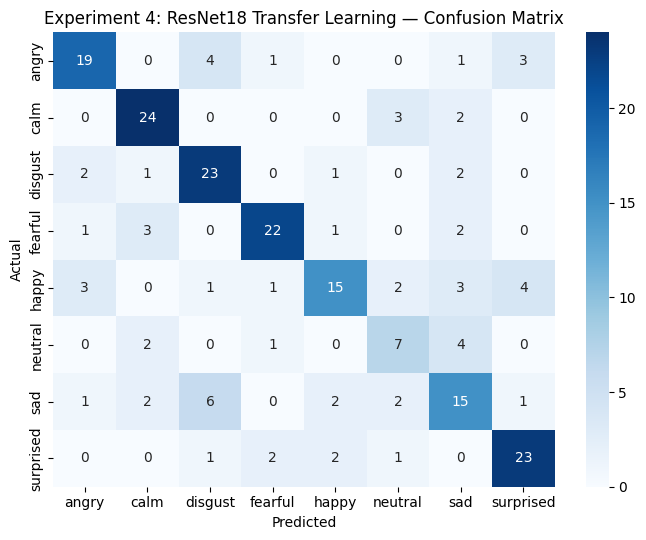

In [26]:
plot_history(history_4, "Experiment 4: ResNet18 Transfer Learning — Loss Curves")

test_acc_4, yt_4, yp_4 = evaluate(model_4, test_loader_4)
train_acc_4, _, _ = evaluate(model_4, train_loader_4)

print(f"Train Accuracy: {train_acc_4:.4f}")
print(f"Test Accuracy:  {test_acc_4:.4f}")
print(f"Train/Test gap: {train_acc_4 - test_acc_4:.4f}")

print(classification_report(yt_4, yp_4, target_names=encoder.classes_))
plot_confusion(yt_4, yp_4, "Experiment 4: ResNet18 Transfer Learning — Confusion Matrix")

results["4. Transfer Learning (ResNet18)"] = {
    "train_acc": train_acc_4, "test_acc": test_acc_4,
    "gap": train_acc_4 - test_acc_4
}

## Experiment 5 — Transfer Learning + Augmentation (ResNet18 + SpecAugment + Mixup)

Combines Experiments 3 and 4: the same pretrained, partially-frozen ResNet18 from Experiment 4,
trained with SpecAugment + Mixup on the training data. This tells us whether augmentation still
helps once a strong pretrained backbone is already doing a lot of the generalization work for
us — it's a genuinely open question rather than an obvious win, since pretrained backbones can
sometimes need less augmentation than from-scratch models.

In [27]:
set_seed(SEED)

train_dataset_5 = AugmentedAudioDataset(X_train_norm, y_train, train=True)
val_dataset_5 = AudioDataset(X_val_norm, y_val)
test_dataset_5 = AudioDataset(X_test_norm, y_test)

train_loader_5 = DataLoader(train_dataset_5, batch_size=16, shuffle=True)
val_loader_5 = DataLoader(val_dataset_5, batch_size=16)
test_loader_5 = DataLoader(test_dataset_5, batch_size=16)

model_5 = build_resnet18_for_mel(
    num_classes=len(encoder.classes_),
    freeze_layers=("conv1", "bn1", "layer1","layer2")
).to(device)

criterion_5 = nn.CrossEntropyLoss()

optimizer_5 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_5.parameters()),
    lr=1e-4,
    weight_decay=5e-0
)

scheduler_5 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_5, mode="min", factor=0.5, patience=5, min_lr=1e-6
)

model_5, history_5 = train_model(
    model_5, train_loader_5, val_loader_5, optimizer_5, scheduler_5,
    criterion=criterion_5, num_epochs=200, patience=50, use_mixup=True,
    num_classes=len(encoder.classes_), model_name="exp5_resnet18_augmented"
)

Epoch 001 | Train Loss=1.9994 | Val Loss=1.8202 | LR=0.000100
Epoch 005 | Train Loss=1.4257 | Val Loss=1.1295 | LR=0.000100
Epoch 010 | Train Loss=1.1896 | Val Loss=0.8786 | LR=0.000100
Epoch 015 | Train Loss=1.0785 | Val Loss=0.8344 | LR=0.000100
Epoch 020 | Train Loss=1.0118 | Val Loss=0.7994 | LR=0.000100
Epoch 025 | Train Loss=0.9518 | Val Loss=0.7880 | LR=0.000100
Epoch 030 | Train Loss=0.7693 | Val Loss=0.7148 | LR=0.000100
Epoch 035 | Train Loss=0.8142 | Val Loss=0.7151 | LR=0.000100
Epoch 040 | Train Loss=0.7233 | Val Loss=0.6915 | LR=0.000050
Epoch 045 | Train Loss=0.6487 | Val Loss=0.7086 | LR=0.000050
Epoch 050 | Train Loss=0.5759 | Val Loss=0.6507 | LR=0.000025
Epoch 055 | Train Loss=0.5609 | Val Loss=0.6569 | LR=0.000013
Epoch 060 | Train Loss=0.4635 | Val Loss=0.6599 | LR=0.000013
Epoch 065 | Train Loss=0.4992 | Val Loss=0.6499 | LR=0.000013
Epoch 070 | Train Loss=0.5699 | Val Loss=0.6306 | LR=0.000006
Epoch 075 | Train Loss=0.5201 | Val Loss=0.6445 | LR=0.000003
Epoch 08

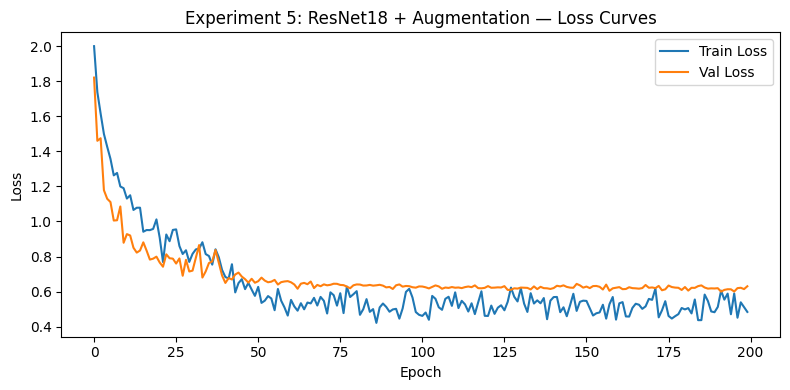

Train Accuracy (clean, no augmentation): 1.0000
Test Accuracy:                           0.8704
Train/Test gap:                          0.1296
              precision    recall  f1-score   support

       angry       0.84      0.93      0.88        28
        calm       0.90      0.93      0.92        29
     disgust       0.87      0.93      0.90        29
     fearful       0.93      0.90      0.91        29
       happy       0.85      0.79      0.82        29
     neutral       0.91      0.71      0.80        14
         sad       0.78      0.72      0.75        29
   surprised       0.90      0.97      0.93        29

    accuracy                           0.87       216
   macro avg       0.87      0.86      0.86       216
weighted avg       0.87      0.87      0.87       216



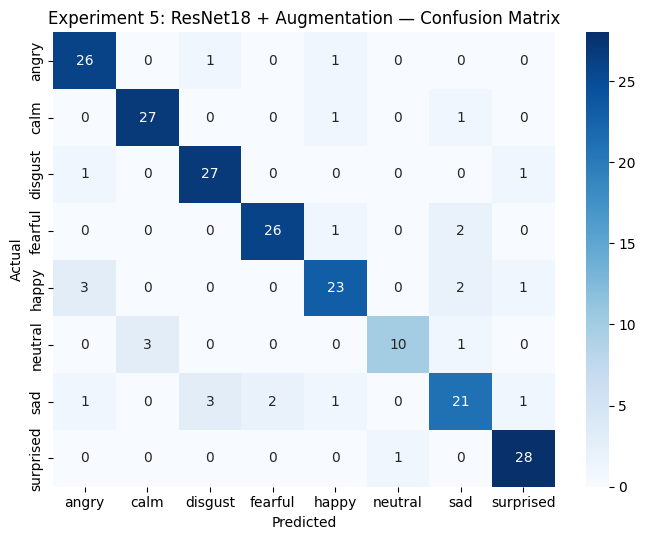

In [28]:
plot_history(history_5, "Experiment 5: ResNet18 + Augmentation — Loss Curves")

test_acc_5, yt_5, yp_5 = evaluate(model_5, test_loader_5)

clean_train_loader_5 = DataLoader(AudioDataset(X_train_norm, y_train), batch_size=32)
train_acc_5_clean, _, _ = evaluate(model_5, clean_train_loader_5)

print(f"Train Accuracy (clean, no augmentation): {train_acc_5_clean:.4f}")
print(f"Test Accuracy:                           {test_acc_5:.4f}")
print(f"Train/Test gap:                          {train_acc_5_clean - test_acc_5:.4f}")

print(classification_report(yt_5, yp_5, target_names=encoder.classes_))
plot_confusion(yt_5, yp_5, "Experiment 5: ResNet18 + Augmentation — Confusion Matrix")

results["5. Transfer Learning + Augmentation"] = {
    "train_acc": train_acc_5_clean, "test_acc": test_acc_5,
    "gap": train_acc_5_clean - test_acc_5
}

## Final Comparison

All 5 experiments were trained and evaluated on the exact same stratified train/val/test split
and the same normalization, so the differences below isolate the effect of each technique.

In [29]:
results_df = pd.DataFrame(results).T
results_df = results_df.rename(columns={
    "train_acc": "Train Accuracy", "test_acc": "Test Accuracy", "gap": "Train–Test Gap"
})
results_df = results_df[["Train Accuracy", "Test Accuracy", "Train–Test Gap"]].round(4)
results_df

,Train Accuracy,Test Accuracy,Train–Test Gap
1. Baseline CNN,0.6300,0.5324,0.0976
2. Regularized CNN,0.6260,0.6065,0.0195
3. Regularized CNN + Augmentation,0.8988,0.6759,0.2229
4. Transfer Learning (ResNet18),1.0000,0.6852,0.3148
5. Transfer Learning + Augmentation,1.0000,0.8704,0.1296


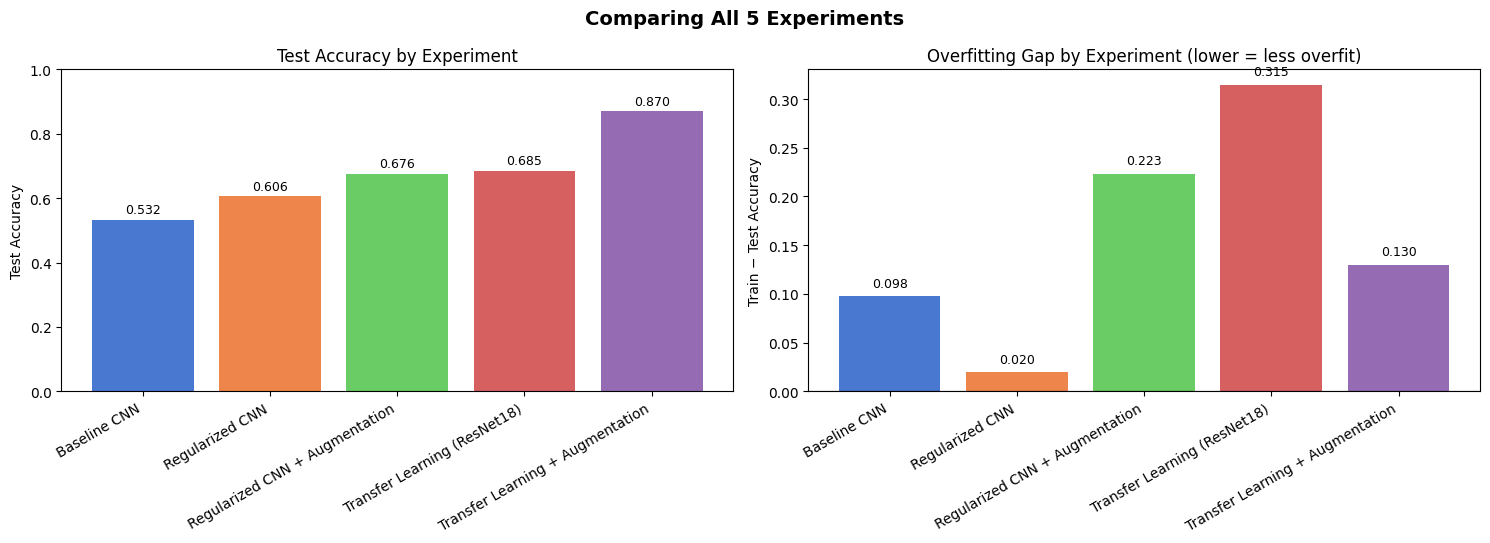

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

x_labels = list(results.keys())
test_accs = [results[k]["test_acc"] for k in x_labels]
gaps = [results[k]["gap"] for k in x_labels]
short_labels = [k.split(". ", 1)[1] for k in x_labels]

colors = sns.color_palette("muted", len(x_labels))

axes[0].bar(range(len(x_labels)), test_accs, color=colors)
axes[0].set_xticks(range(len(x_labels)))
axes[0].set_xticklabels(short_labels, rotation=30, ha="right")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Test Accuracy by Experiment")
axes[0].set_ylim(0, 1)
for i, v in enumerate(test_accs):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

axes[1].bar(range(len(x_labels)), gaps, color=colors)
axes[1].set_xticks(range(len(x_labels)))
axes[1].set_xticklabels(short_labels, rotation=30, ha="right")
axes[1].set_ylabel("Train − Test Accuracy")
axes[1].set_title("Overfitting Gap by Experiment (lower = less overfit)")
axes[1].axhline(0, color="black", linewidth=0.8)
for i, v in enumerate(gaps):
    axes[1].text(i, v + 0.01 if v >= 0 else v - 0.03, f"{v:.3f}", ha="center", fontsize=9)

plt.suptitle("Comparing All 5 Experiments", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Insights

* The baseline CNN serves as a simple reference architecture capable of learning basic emotion-related patterns from mel-spectrograms. Its low training performance indicates that the model is underfitting and lacks sufficient representational capacity to capture the complexity of the task. Consequently, its small train-test gap reflects limited learning rather than strong generalization.

* Introducing regularization techniques, including Batch Normalization, Dropout, weight decay, adaptive learning-rate scheduling, and early stopping, substantially improves both the learning capability and classification performance of the CNN. Despite the increased model capacity, the train-test gap remains relatively modest, indicating that these regularization techniques effectively control overfitting while allowing the network to learn more discriminative features.

* Increasing the depth of the CNN and incorporating SpecAugment and MixUp further improves classification accuracy compared with the previous CNN architectures. However, these improvements are accompanied by a considerably larger train-test gap, indicating that the more expressive network begins to memorize the training data. In this case, the augmentation techniques increase predictive performance but are not sufficient to fully prevent overfitting when training the network entirely from scratch.

* Replacing the handcrafted CNN with a pretrained ResNet18 demonstrates the effectiveness of transfer learning. The pretrained backbone provides significantly richer feature representations than can be learned from the limited RAVDESS dataset alone, leading to improved recognition performance over the CNN-based models. However, the model almost perfectly fits the training data, producing the largest train-test gap among all experiments and indicating substantial overfitting.

* Combining transfer learning with SpecAugment and MixUp produces the strongest overall performance. While the model still memorizes the training set, the augmentation strategies substantially improve the robustness of the pretrained representations, resulting in a noticeably smaller train-test gap than transfer learning alone and the highest test accuracy across all experiments. This demonstrates that data augmentation is considerably more effective when applied to a strong pretrained feature extractor than when used with CNNs trained entirely from scratch.

---

### Overall Conclusion

The experiments demonstrate that increasing model complexity alone does not guarantee better generalization. Although deeper CNN architectures and transfer learning models achieve progressively higher predictive performance, they also become increasingly capable of memorizing the limited training data. Consequently, improvements in test accuracy are often accompanied by larger train-test gaps rather than reductions in overfitting.

Transfer learning provides the most significant improvement because the pretrained ResNet18 begins with rich and transferable feature representations learned from a large-scale dataset. Instead of learning low-level acoustic patterns from only a small number of speech recordings, the model can focus on adapting high-level representations to the emotion recognition task, resulting in substantially better classification performance.

Finally, the experiments highlight that the effectiveness of data augmentation depends strongly on the quality of the underlying feature extractor. When combined with CNNs trained from scratch, augmentation alone cannot fully overcome the limitations imposed by the small dataset and deeper architectures remain prone to overfitting. In contrast, when applied to the pretrained ResNet18, the same augmentation techniques act as effective regularizers, reducing overfitting relative to the transfer learning baseline while simultaneously producing the best overall recognition performance. These findings suggest that, for small speech emotion datasets such as RAVDESS, pretrained feature extractors combined with appropriate augmentation provide a more effective strategy than attempting to learn increasingly complex CNNs from scratch.